#### 0. Инициализация

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt

from signals import generate_signal, read_signal
from fft_time_decimation import fft_dit, ifft_dit
from convolution import conv_time, conv_fft
from correlation import corr_time, corr_fft

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['grid.alpha'] = 0.3


#### 1a. Генерация сигналов x и y

In [2]:
# параметры
fs = 400        # частота дискретизации, Гц
duration = 3.0    # длительность, c

def sigX_func(t: np.ndarray) -> np.ndarray:
    return 2 * np.sin(3 * t) + np.cos(2 * t + 1)

generate_signal('sigX.wav', sigX_func, fs=fs, duration=duration)
print("Файл sigX.wav сгенерирован.")

def sigY_func(t: np.ndarray) -> np.ndarray:
    return 1.5 * np.sin(5 * t + 0.5) + 0.5 * np.cos(4 * t)

generate_signal('sigY.wav', sigY_func, fs=fs, duration=duration)
print("Файл sigY.wav сгенерирован.")

Файл sigX.wav сгенерирован.
Файл sigY.wav сгенерирован.


#### 1b. Чтение сигналов

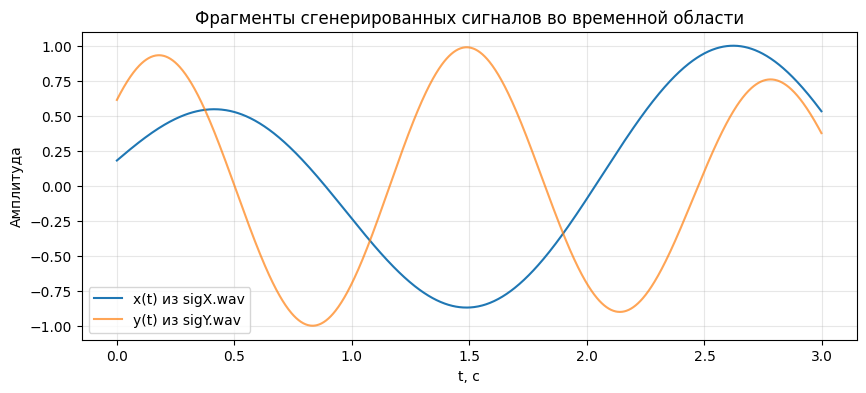

In [3]:
fs1, x = read_signal('sigX.wav')
fs2, y = read_signal('sigY.wav')

t = np.arange(len(x)) / fs1
max_time = 3
mask = t < max_time

plt.plot(t[mask], x[mask], label='x(t) из sigX.wav')
plt.plot(t[mask], y[mask], label='y(t) из sigY.wav', alpha=0.7)
plt.xlabel('t, c')
plt.ylabel('Амплитуда')
plt.title('Фрагменты сгенерированных сигналов во временной области')
plt.grid(True)
plt.legend()
plt.show()


#### 2a. Свёртка двух сигналов во временной области

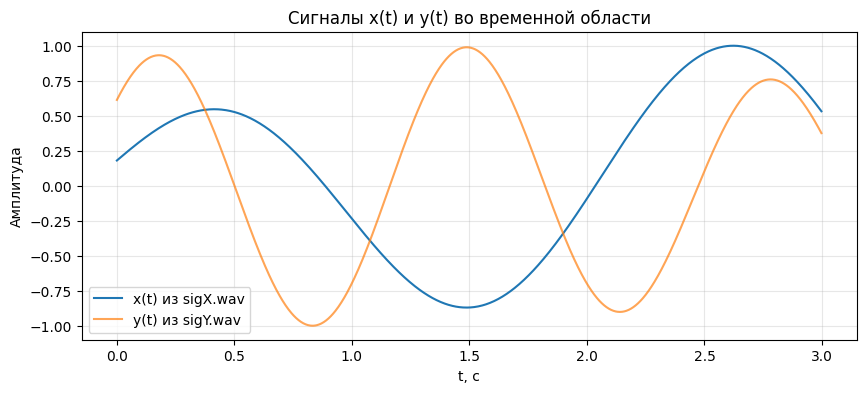

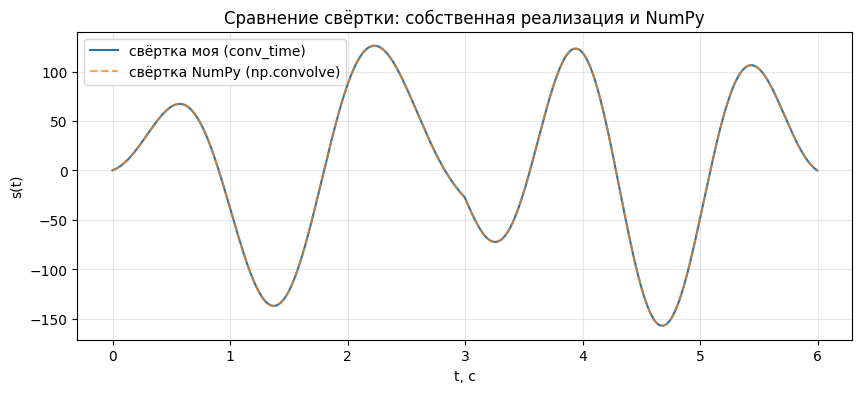

Максимальное расхождение: 2.131369313929099e-05


In [4]:
# подготовка сигналов для свертки
x_list = [complex(val) for val in x]
y_list = [complex(val) for val in y]

len_x = len(x_list)
len_y = len(y_list)

# 1. Графики x(t) и y(t) на всём интервале
t = np.arange(len(x)) / fs1

plt.figure(figsize=(10, 4))
plt.plot(t, x, label='x(t) из sigX.wav')
plt.plot(t, y, label='y(t) из sigY.wav', alpha=0.7)
plt.xlabel('t, c')
plt.ylabel('Амплитуда')
plt.title('Сигналы x(t) и y(t) во временной области')
plt.grid(True)
plt.legend()
plt.show()

# 2. Свёртка

# подготовка списков комплексных значений для conv_time
x_list = [complex(val) for val in x]
y_list = [complex(val) for val in y]

# свёртка (моя)
s_time = conv_time(x_list, y_list)
s_time_np = np.array(s_time)

# свёртка через NumPy
s_np = np.convolve(x, y, mode='full')

L = len(s_time_np)
t_conv = np.arange(L) / fs1

# 3. Сравнение результатов свёртки на одном графике
plt.figure(figsize=(10, 4))
plt.plot(t_conv, s_time_np.real, label='свёртка моя (conv_time)')
plt.plot(t_conv, s_np, '--', label='свёртка NumPy (np.convolve)', alpha=0.7)
plt.xlabel('t, c')
plt.ylabel('s(t)')
plt.title('Сравнение свёртки: собственная реализация и NumPy')
plt.grid(True)
plt.legend()
plt.show()

print("Максимальное расхождение:",
      np.max(np.abs(s_time_np.real - s_np)))

#### 2b. Корреляция двух сигналов во временной области

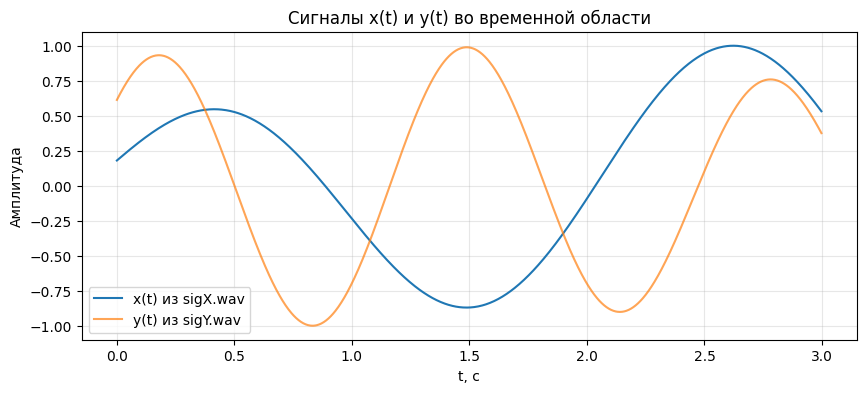

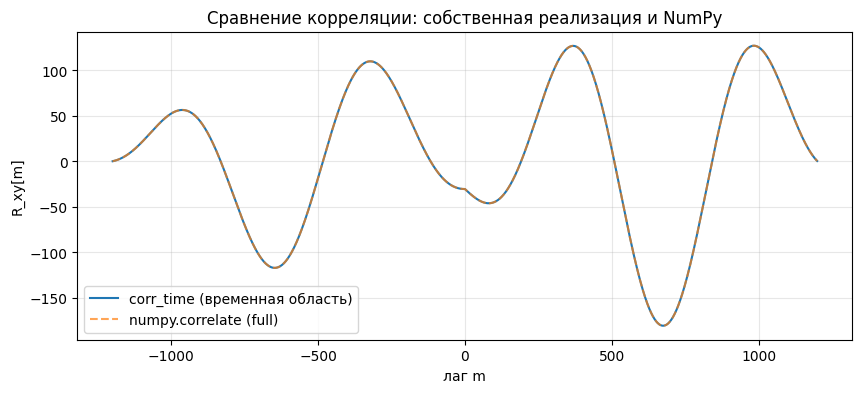

Максимальное расхождение: 2.0670807344913555e-05


In [5]:
# 1. Сигналы x(t) и y(t) 
t = np.arange(len(x)) / fs1

plt.figure(figsize=(10, 4))
plt.plot(t, x, label='x(t) из sigX.wav')
plt.plot(t, y, label='y(t) из sigY.wav', alpha=0.7)
plt.xlabel('t, c')
plt.ylabel('Амплитуда')
plt.title('Сигналы x(t) и y(t) во временной области')
plt.grid(True)
plt.legend()
plt.show()

# 2. Корреляция моя

x_list = [complex(val) for val in x]
y_list = [complex(val) for val in y]

r_xy_time = corr_time(x_list, y_list)   # моя
r_xy_time_np = np.array(r_xy_time)      

N = len(x)
m_values = np.arange(-(N-1), N)

# 3. Корреляция через NumPy

r_xy_np = np.correlate(x, y, mode='full')

# 4. Сравнение результатов

plt.figure(figsize=(10, 4))
plt.plot(m_values, r_xy_time_np.real, label='corr_time (временная область)')
plt.plot(m_values, r_xy_np, '--', label='numpy.correlate (full)', alpha=0.7)
plt.xlabel('лаг m')
plt.ylabel('R_xy[m]')
plt.title('Сравнение корреляции: собственная реализация и NumPy')
plt.grid(True)
plt.legend()
plt.show()

print("Максимальное расхождение:",
      np.max(np.abs(r_xy_time_np.real - r_xy_np)))


#### 2c. FFT & IFFT

Длины после дополнения до степени двойки: x: 2048 y: 2048 s: 4096


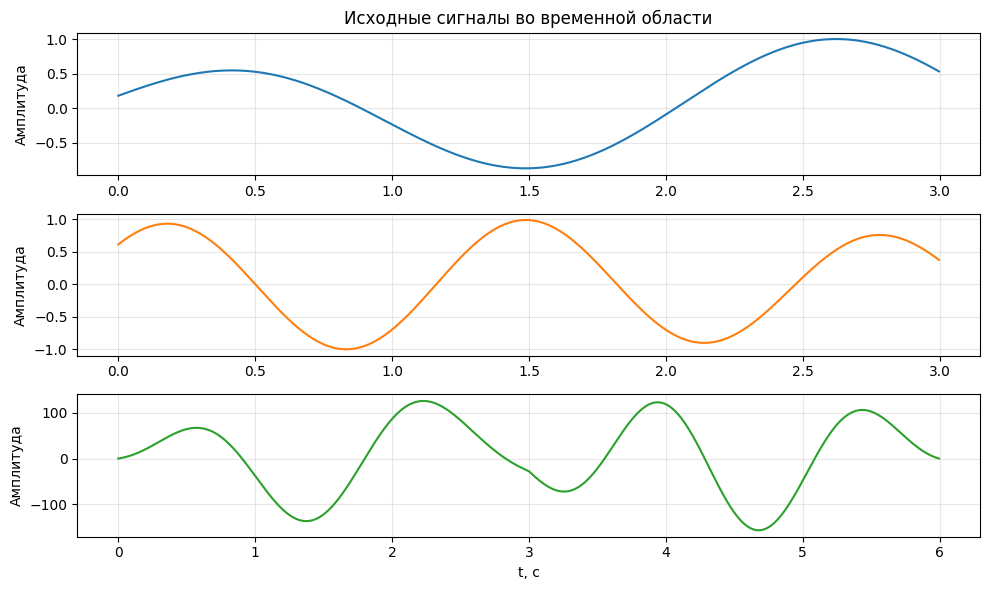

Макс. расхождение спектров X: 5.0776519400818825e-12
Макс. расхождение спектров Y: 5.6548489052437876e-12
Макс. расхождение спектров S: 4.45072176873885e-09


In [6]:
# 1. Подготовка трёх сигналов: x, y и s
s = s_time_np.real  

# чтобы использовать рекурсивный БПФ, длины должны быть степенью двойки
def pad_to_pow2(z: np.ndarray):
    N = len(z)
    N_fft = 1
    while N_fft < N:
        N_fft *= 2
    z_pad = np.zeros(N_fft, dtype=complex)
    z_pad[:N] = z.astype(complex)
    return z_pad, N, N_fft

x_pad, Nx, Nx_fft = pad_to_pow2(x)
y_pad, Ny, Ny_fft = pad_to_pow2(y)
s_pad, Ns, Ns_fft = pad_to_pow2(s)

print("Длины после дополнения до степени двойки:",
      "x:", Nx_fft, "y:", Ny_fft, "s:", Ns_fft)

# 2. Прямое БПФ: моя реализация и NumPy
X_fft = fft_dit(list(x_pad))
Y_fft = fft_dit(list(y_pad))
S_fft = fft_dit(list(s_pad))

X_np = np.fft.fft(x_pad)
Y_np = np.fft.fft(y_pad)
S_np = np.fft.fft(s_pad)

# 3. Один график с исходными сигналами во времени
t_x = np.arange(Nx) / fs1
t_y = np.arange(Ny) / fs1
t_s = np.arange(Ns) / fs1

plt.figure(figsize=(10, 6))
plt.subplot(3, 1, 1)
plt.plot(t_x, x, label='x(t)')
plt.ylabel('Амплитуда')
plt.title('Исходные сигналы во временной области')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t_y, y, label='y(t)', color='C1')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t_s, s, label='s(t) = x*y', color='C2')
plt.xlabel('t, c')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.tight_layout()
plt.show()

# 4. Сравнение своей реализации и NumPy для каждого сигнала
freq_x = np.fft.fftfreq(Nx_fft, d=1/fs1)
freq_y = np.fft.fftfreq(Ny_fft, d=1/fs1)
freq_s = np.fft.fftfreq(Ns_fft, d=1/fs1)

X_fft_np = np.array(X_fft)
Y_fft_np = np.array(Y_fft)
S_fft_np = np.array(S_fft)

print("Макс. расхождение спектров X:", np.max(np.abs(X_fft_np - X_np)))
print("Макс. расхождение спектров Y:", np.max(np.abs(Y_fft_np - Y_np)))
print("Макс. расхождение спектров S:", np.max(np.abs(S_fft_np - S_np)))


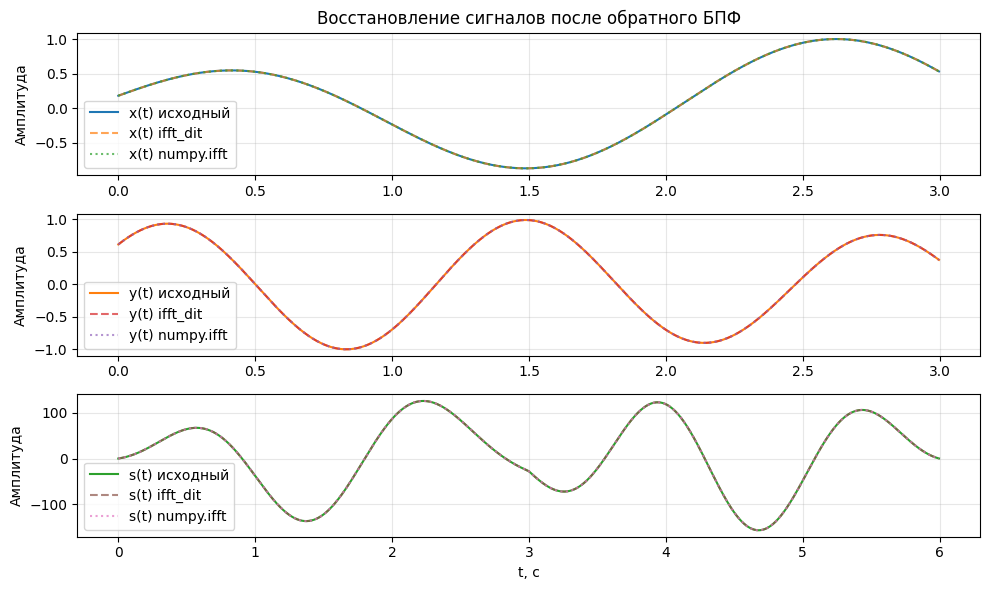

Макс. расхождение x vs ifft_dit: 1.9984014443252818e-14
Макс. расхождение x vs numpy.ifft: 4.440892098500626e-16
Макс. расхождение y vs ifft_dit: 1.7319479184152442e-14
Макс. расхождение y vs numpy.ifft: 4.440892098500626e-16
Макс. расхождение s vs ifft_dit: 1.1738165994756855e-11
Макс. расхождение s vs numpy.ifft: 8.526512829121202e-14


In [7]:
# 5. Обратное БПФ (моя)
x_rec_full = np.array(ifft_dit(list(X_fft)))
y_rec_full = np.array(ifft_dit(list(Y_fft)))
s_rec_full = np.array(ifft_dit(list(S_fft)))

# 6. Обратное БПФ через NumPy
x_ifft_np_full = np.fft.ifft(X_np)
y_ifft_np_full = np.fft.ifft(Y_np)
s_ifft_np_full = np.fft.ifft(S_np)

# 7. Берём только первые длины исходных сигналов
Nx = len(x)
Ny = len(y)
Ns = len(s)

x_rec = x_rec_full[:Nx]
y_rec = y_rec_full[:Ny]
s_rec = s_rec_full[:Ns]

x_ifft_np = x_ifft_np_full[:Nx]
y_ifft_np = y_ifft_np_full[:Ny]
s_ifft_np = s_ifft_np_full[:Ns]

plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.plot(t_x, x, label='x(t) исходный')
plt.plot(t_x, x_rec.real, '--', label='x(t) ifft_dit', alpha=0.7)
plt.plot(t_x, x_ifft_np.real, ':', label='x(t) numpy.ifft', alpha=0.7)
plt.ylabel('Амплитуда')
plt.title('Восстановление сигналов после обратного БПФ')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t_y, y, label='y(t) исходный', color='C1')
plt.plot(t_y, y_rec.real, '--', label='y(t) ifft_dit', alpha=0.7, color='C3')
plt.plot(t_y, y_ifft_np.real, ':', label='y(t) numpy.ifft', alpha=0.7, color='C4')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t_s, s, label='s(t) исходный', color='C2')
plt.plot(t_s, s_rec.real, '--', label='s(t) ifft_dit', alpha=0.7, color='C5')
plt.plot(t_s, s_ifft_np.real, ':', label='s(t) numpy.ifft', alpha=0.7, color='C6')
plt.xlabel('t, c')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("Макс. расхождение x vs ifft_dit:", np.max(np.abs(x - x_rec.real)))
print("Макс. расхождение x vs numpy.ifft:", np.max(np.abs(x - x_ifft_np.real)))
print("Макс. расхождение y vs ifft_dit:", np.max(np.abs(y - y_rec.real)))
print("Макс. расхождение y vs numpy.ifft:", np.max(np.abs(y - y_ifft_np.real)))
print("Макс. расхождение s vs ifft_dit:", np.max(np.abs(s - s_rec.real)))
print("Макс. расхождение s vs numpy.ifft:", np.max(np.abs(s - s_ifft_np.real)))


#### 2d. Амплитудные и фазовые спектры сигналов x, y и s (Stem)

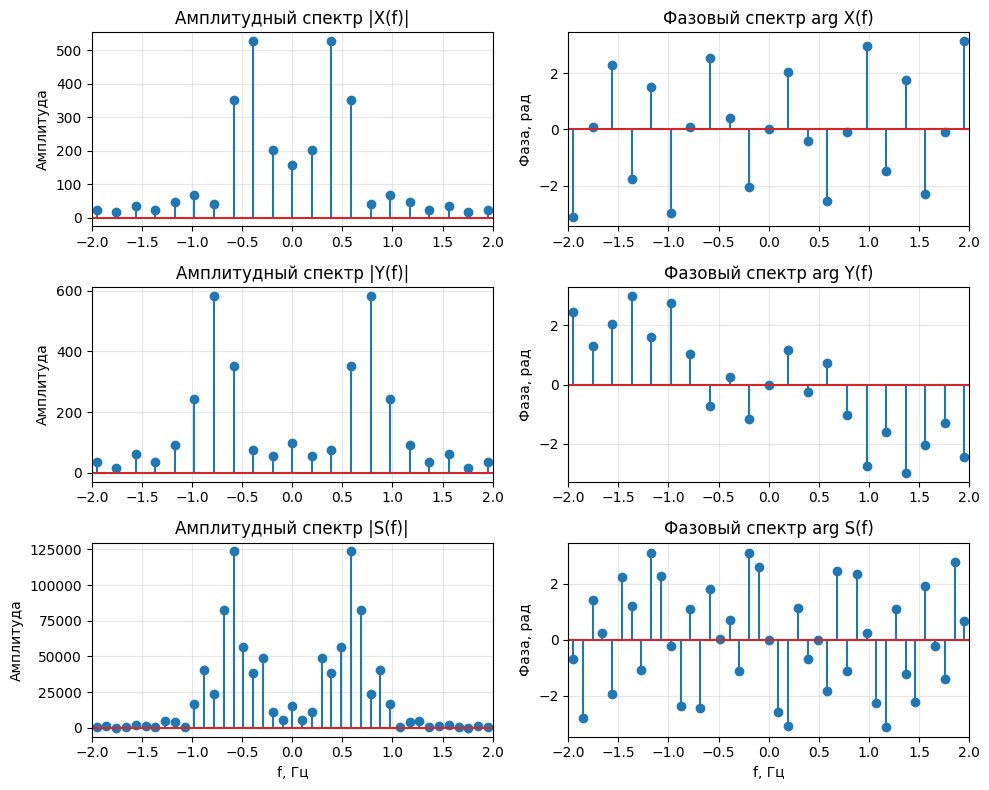

In [21]:
X_fft_np = np.array(X_fft)
Y_fft_np = np.array(Y_fft)
S_fft_np = np.array(S_fft)

Amp_X = np.abs(X_fft_np)
Amp_Y = np.abs(Y_fft_np)
Amp_S = np.abs(S_fft_np)

Phase_X = np.angle(X_fft_np)
Phase_Y = np.angle(Y_fft_np)
Phase_S = np.angle(S_fft_np)

plt.figure(figsize=(10, 8))

# Амплитудные спектры
plt.subplot(3, 2, 1)
#plt.plot(freq_x, Amp_X)
plt.stem(freq_x, Amp_X)
plt.xlim(-2, 2)
plt.ylabel('Амплитуда')
plt.title('Амплитудный спектр |X(f)|')
plt.grid(True)

plt.subplot(3, 2, 3)
#plt.plot(freq_y, Amp_Y, color='C1')
plt.stem(freq_y, Amp_Y)
plt.xlim(-2, 2)
plt.ylabel('Амплитуда')
plt.title('Амплитудный спектр |Y(f)|')
plt.grid(True)

plt.subplot(3, 2, 5)
#plt.plot(freq_s, Amp_S, color='C2')
plt.stem(freq_s, Amp_S)
plt.xlim(-2, 2)
plt.xlabel('f, Гц')
plt.ylabel('Амплитуда')
plt.title('Амплитудный спектр |S(f)|')
plt.grid(True)

# Фазовые спектры
plt.subplot(3, 2, 2)
#plt.plot(freq_x, Phase_X)
plt.stem(freq_x, Phase_X)
plt.xlim(-2, 2)
plt.ylabel('Фаза, рад')
plt.title('Фазовый спектр arg X(f)')
plt.grid(True)

plt.subplot(3, 2, 4)
#plt.plot(freq_y, Phase_Y, color='C1')
plt.stem(freq_y, Phase_Y)
plt.xlim(-2, 2)
plt.ylabel('Фаза, рад')
plt.title('Фазовый спектр arg Y(f)')
plt.grid(True)

plt.subplot(3, 2, 6)
#plt.plot(freq_s, Phase_S, color='C2')
plt.stem(freq_s, Phase_S)
plt.xlim(-2, 2)
plt.xlabel('f, Гц')
plt.ylabel('Фаза, рад')
plt.title('Фазовый спектр arg S(f)')
plt.grid(True)

plt.tight_layout()
plt.show()


#### 2d. Амплитудные и фазовые спектры сигналов x, y и s (Plot)

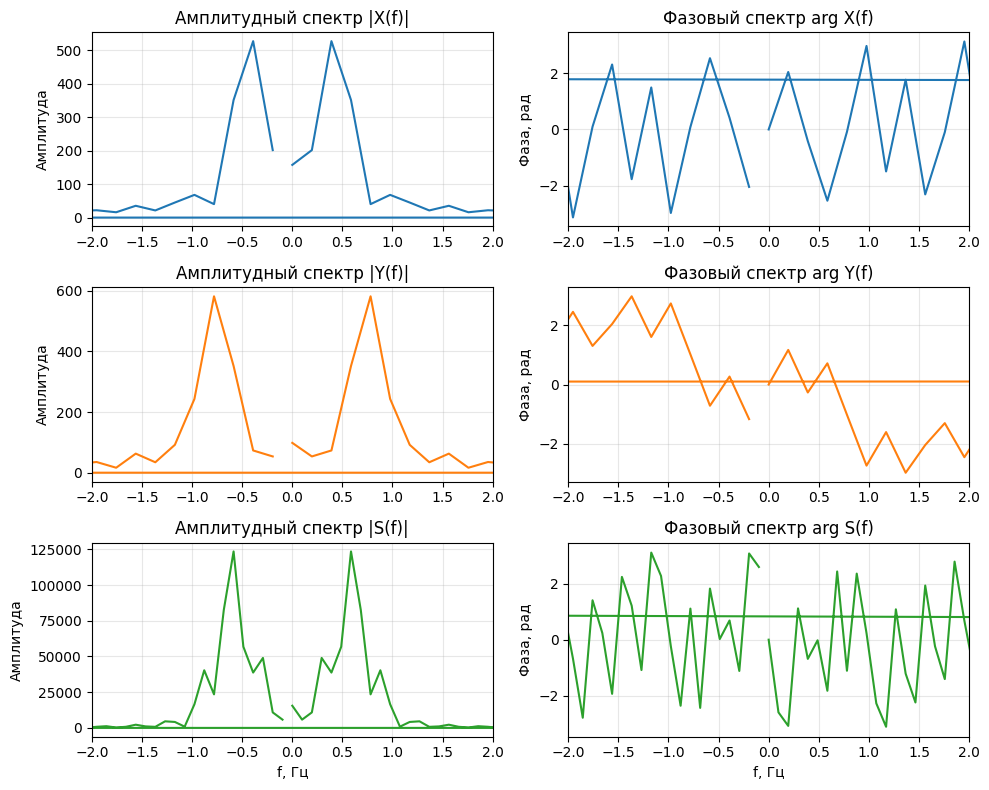

In [22]:
plt.figure(figsize=(10, 8))

# Амплитудные спектры
plt.subplot(3, 2, 1)
plt.plot(freq_x, Amp_X)
#plt.stem(freq_x, Amp_X)
plt.xlim(-2, 2)
plt.ylabel('Амплитуда')
plt.title('Амплитудный спектр |X(f)|')
plt.grid(True)

plt.subplot(3, 2, 3)
plt.plot(freq_y, Amp_Y, color='C1')
#plt.stem(freq_y, Amp_Y)
plt.xlim(-2, 2)
plt.ylabel('Амплитуда')
plt.title('Амплитудный спектр |Y(f)|')
plt.grid(True)

plt.subplot(3, 2, 5)
plt.plot(freq_s, Amp_S, color='C2')
#plt.stem(freq_s, Amp_S)
plt.xlim(-2, 2)
plt.xlabel('f, Гц')
plt.ylabel('Амплитуда')
plt.title('Амплитудный спектр |S(f)|')
plt.grid(True)

# Фазовые спектры
plt.subplot(3, 2, 2)
plt.plot(freq_x, Phase_X)
#plt.stem(freq_x, Phase_X)
plt.xlim(-2, 2)
plt.ylabel('Фаза, рад')
plt.title('Фазовый спектр arg X(f)')
plt.grid(True)

plt.subplot(3, 2, 4)
plt.plot(freq_y, Phase_Y, color='C1')
#plt.stem(freq_y, Phase_Y)
plt.xlim(-2, 2)
plt.ylabel('Фаза, рад')
plt.title('Фазовый спектр arg Y(f)')
plt.grid(True)

plt.subplot(3, 2, 6)
plt.plot(freq_s, Phase_S, color='C2')
#plt.stem(freq_s, Phase_S)
plt.xlim(-2, 2)
plt.xlabel('f, Гц')
plt.ylabel('Фаза, рад')
plt.title('Фазовый спектр arg S(f)')
plt.grid(True)

plt.tight_layout()
plt.show()

#### 2e. Графики сигналов во временной области

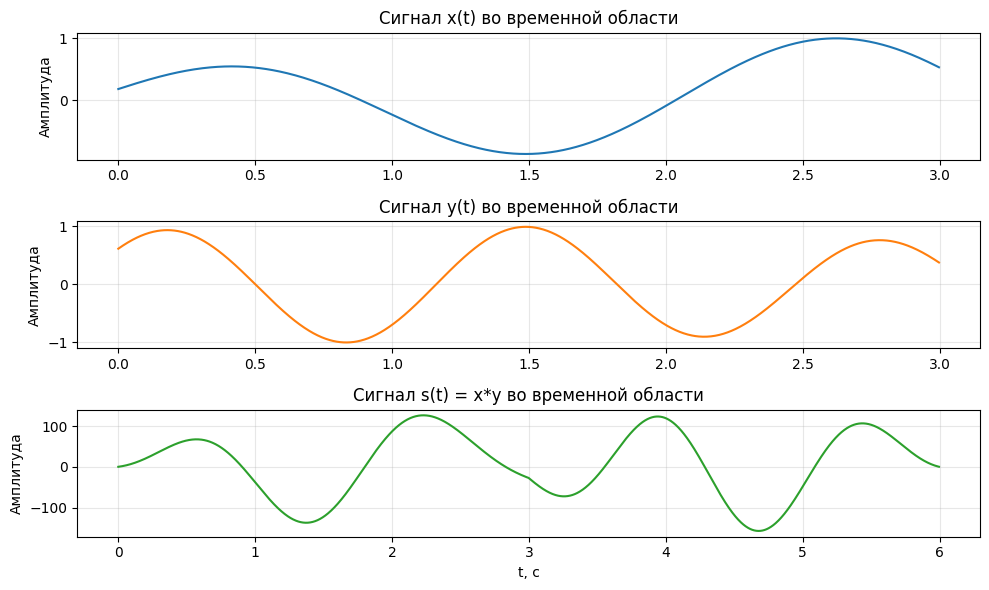

In [9]:
# исходные сигналы x(t), y(t) и свёртка s(t)
s = s_time_np.real 

t_x = np.arange(len(x)) / fs1
t_y = np.arange(len(y)) / fs1
t_s = np.arange(len(s)) / fs1

plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.plot(t_x, x)
plt.ylabel('Амплитуда')
plt.title('Сигнал x(t) во временной области')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t_y, y, color='C1')
plt.ylabel('Амплитуда')
plt.title('Сигнал y(t) во временной области')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t_s, s, color='C2')
plt.xlabel('t, c')
plt.ylabel('Амплитуда')
plt.title('Сигнал s(t) = x*y во временной области')
plt.grid(True)

plt.tight_layout()
plt.show()


#### 2f. Проверка свёртки и корреляции через Фурье-преобразование

Свёртка:
max |s_time - s_fft| = 1.0061285138363019e-11
max |s_time - s_np | = 2.131369313929099e-05
max |s_fft  - s_np | = 2.1313701267899887e-05


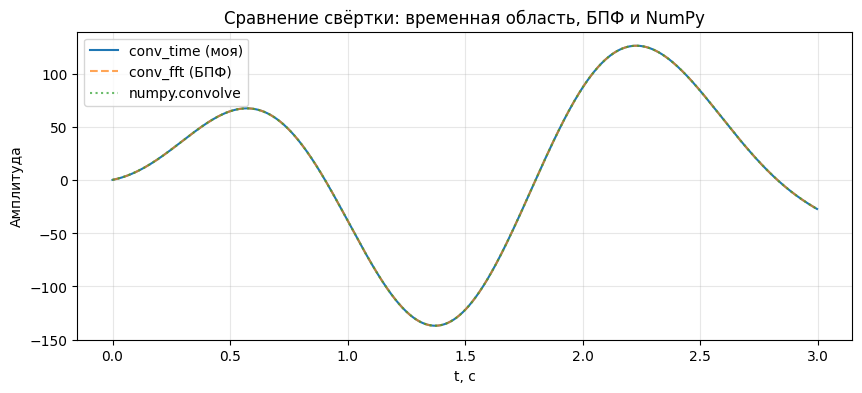

In [10]:
# подготовка списков complex
x_list = [complex(val) for val in x]
y_list = [complex(val) for val in y]

# 1. Свёртка во временной области (моя)
s_time = np.array(conv_time(x_list, y_list))

# 2. Свёртка через БПФ (моя)
s_fft = np.array(conv_fft(x_list, y_list))

# 3. Свёртка через NumPy (эталон)
s_np = np.convolve(x, y, mode='full')  

# 4. Сравнение по максимуму расхождения
print("Свёртка:")
print("max |s_time - s_fft| =", np.max(np.abs(s_time.real - s_fft.real)))
print("max |s_time - s_np | =", np.max(np.abs(s_time.real - s_np)))
print("max |s_fft  - s_np | =", np.max(np.abs(s_fft.real  - s_np)))

# 5. Графическое сравнение (фрагмент)
L = len(s_np)
t_conv = np.arange(L) / fs1

max_time_conv = 3  # показать первые 3 сек результата
mask = t_conv < max_time_conv

plt.figure(figsize=(10, 4))
plt.plot(t_conv[mask], s_time.real[mask], label='conv_time (моя)')
plt.plot(t_conv[mask], s_fft.real[mask], '--', label='conv_fft (БПФ)', alpha=0.7)
plt.plot(t_conv[mask], s_np[mask], ':', label='numpy.convolve', alpha=0.7)
plt.xlabel('t, c')
plt.ylabel('Амплитуда')
plt.title('Сравнение свёртки: временная область, БПФ и NumPy')
plt.grid(True)
plt.legend()
plt.show()


Корреляция:
max |r_time - r_fft| = 8.469669410260394e-12
max |r_time - r_np | = 2.0670807344913555e-05
max |r_fft  - r_np | = 2.067079918788295e-05


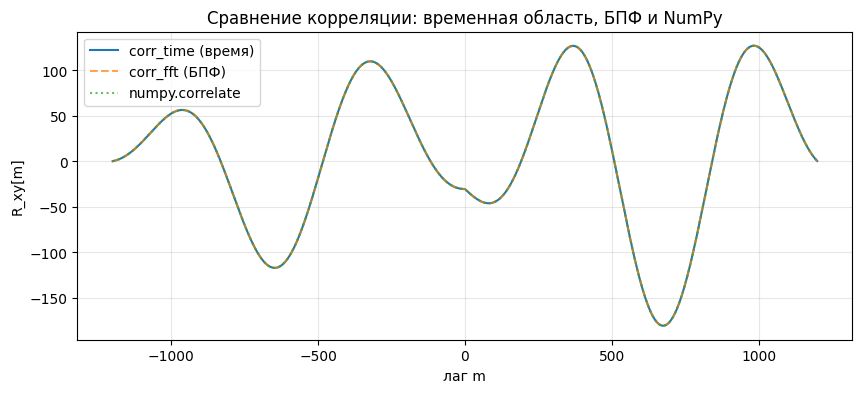

In [11]:
# 1. Корреляция во временной области (моя)
r_time = np.array(corr_time(x_list, y_list))

# 2. Корреляция через БПФ (моя)
r_fft = np.array(corr_fft(x_list, y_list))

# 3. Корреляция через NumPy (эталон)

r_np = np.correlate(x, y, mode='full')

N = len(x)
m_values = np.arange(-(N - 1), N)

print("Корреляция:")
print("max |r_time - r_fft| =", np.max(np.abs(r_time.real - r_fft.real)))
print("max |r_time - r_np | =", np.max(np.abs(r_time.real - r_np)))
print("max |r_fft  - r_np | =", np.max(np.abs(r_fft.real  - r_np)))

# Графическое сравнение
plt.figure(figsize=(10, 4))
plt.plot(m_values, r_time.real, label='corr_time (время)')
plt.plot(m_values, r_fft.real, '--', label='corr_fft (БПФ)', alpha=0.7)
plt.plot(m_values, r_np, ':', label='numpy.correlate', alpha=0.7)
plt.xlabel('лаг m')
plt.ylabel('R_xy[m]')
plt.title('Сравнение корреляции: временная область, БПФ и NumPy')
plt.grid(True)
plt.legend()
plt.show()


#### 3. Влияние числа отсчётов N на эффективность алгоритмов

In [12]:
import time

Ns = [256, 512, 1024, 2048, 4096] 
results_conv = []
results_corr = []

for N in Ns:
    # случайные тестовые сигналы
    xN = np.random.randn(N)
    yN = np.random.randn(N)

    x_list = [complex(val) for val in xN]
    y_list = [complex(val) for val in yN]

    # --- свёртка ---
    t0 = time.perf_counter()
    s_time = conv_time(x_list, y_list)
    t1 = time.perf_counter()
    
    t2 = time.perf_counter()
    s_fft = conv_fft(x_list, y_list)
    t3 = time.perf_counter()
    
    t4 = time.perf_counter()
    s_np = np.convolve(xN, yN, mode='full')
    t5 = time.perf_counter()

    results_conv.append([
        N,
        t1 - t0,   # conv_time
        t3 - t2,   # conv_fft
        t5 - t4    # numpy.convolve
    ])

    # --- корреляция ---
    t0 = time.perf_counter()
    r_time = corr_time(x_list, y_list)
    t1 = time.perf_counter()
    
    t2 = time.perf_counter()
    r_fft = corr_fft(x_list, y_list)
    t3 = time.perf_counter()
    
    t4 = time.perf_counter()
    r_np = np.correlate(xN, yN, mode='full')
    t5 = time.perf_counter()

    results_corr.append([
        N,
        t1 - t0,   # corr_time
        t3 - t2,   # corr_fft
        t5 - t4    # numpy.correlate
    ])

results_conv = np.array(results_conv)
results_corr = np.array(results_corr)

print("Свёртка (время в секундах):")
print("N\tconv_time\tconv_fft\tnp.convolve")
for row in results_conv:
    print(f"{int(row[0])}\t{row[1]:.6f}\t{row[2]:.6f}\t{row[3]:.6f}")

print("\nКорреляция (время в секундах):")
print("N\tcorr_time\tcorr_fft\tnp.correlate")
for row in results_corr:
    print(f"{int(row[0])}\t{row[1]:.6f}\t{row[2]:.6f}\t{row[3]:.6f}")


Свёртка (время в секундах):
N	conv_time	conv_fft	np.convolve
256	0.020605	0.001982	0.000061
512	0.080859	0.005462	0.000075
1024	0.324380	0.009187	0.000163
2048	1.302185	0.026719	0.000562
4096	5.150567	0.042519	0.001964

Корреляция (время в секундах):
N	corr_time	corr_fft	np.correlate
256	0.006474	0.002091	0.000029
512	0.028541	0.004655	0.000054
1024	0.126596	0.010083	0.000160
2048	0.572343	0.024699	0.000440
4096	1.959973	0.040458	0.001807


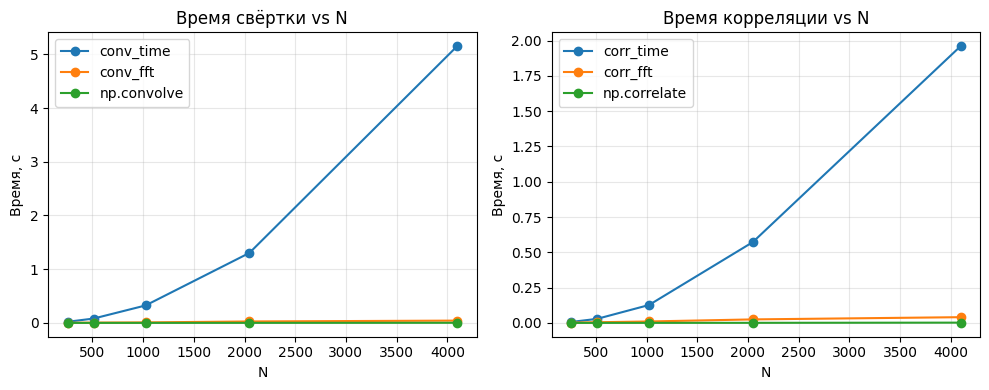

In [13]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(Ns, results_conv[:,1], 'o-', label='conv_time')
plt.plot(Ns, results_conv[:,2], 'o-', label='conv_fft')
plt.plot(Ns, results_conv[:,3], 'o-', label='np.convolve')
plt.xlabel('N')
plt.ylabel('Время, с')
plt.title('Время свёртки vs N')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Ns, results_corr[:,1], 'o-', label='corr_time')
plt.plot(Ns, results_corr[:,2], 'o-', label='corr_fft')
plt.plot(Ns, results_corr[:,3], 'o-', label='np.correlate')
plt.xlabel('N')
plt.ylabel('Время, с')
plt.title('Время корреляции vs N')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
